In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00011
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1123.838423521577
RUN  2 , total integrated cost =  180.0673886162059
RUN  3 , total integrated cost =  93.06692743959917
RUN  4 , total integrated cost =  64.35823483324515
RUN  5 , total integrated cost =  53.85645361531855
RUN  6 , total integrated cost =  44.547777464731
RUN  7 , total integrated cost =  36.35083756617861
RUN  8 , total integrated cost =  28.222785392208447
RUN  9 , total integrated cost =  22.564665998132334
RUN  10 , total integrated cost =  18.395539939567836
RUN  11 , total integrated cost =  16.949585358495057
RUN  12 , total integrated cost =  15.338566301314987
RUN  13 , total integrated cost =  14.40924570330599
RUN  14 , total integrated cost =  14.163872772036239
RUN  15 , total integrated cost =  13.997079405211043
RUN  16 

ERROR:root:Problem in initial value trasfer


RUN  1200 , total integrated cost =  9.85679318289772
Control only changes marginally.
RUN  1202 , total integrated cost =  9.856793182897704
Improved over  1202  iterations in  108.20265308395028  seconds by  99.83300382280399  percent.
Problem in initial value trasfer:  Vmean_exc -56.627619136510646 -56.627619103109524
weight =  5988.161027340529
set cost params:  1.0 0.0 5988.161027340529
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5880.5279563747845
Gradient descend method:  None
RUN  1 , total integrated cost =  5740.411274961464
RUN  2 , total integrated cost =  5738.560163985236
RUN  3 , total integrated cost =  5736.876865530608
RUN  4 , total integrated cost =  5735.152948704991
RUN  5 , total integrated cost =  5734.851030717022
RUN  6 , total integrated cost =  5734.316194406616
RUN  7 , total integrated cost =  5733.981499469503
RUN  8 , total integrated cost =  5732.836607463861
RUN  9 , total integrated cost =  5731.822914495903
RUN  10 , total

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  29 , total integrated cost =  5702.325561148121
Improved over  29  iterations in  3.6207451093941927  seconds by  3.0303808866937345  percent.
Problem in initial value trasfer:  Vmean_exc -56.62693024260001 -56.62693503335029
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  45.86056523241944
RUN  2 , total integrated cost =  17.239807164138576
RUN  3 , total integrated cost =  15.603511585088158
RUN  4 , total integrated cost =  14.726222489766386
RUN  5 , total integrated cost =  13.644380613621433
RUN  6 , total integrated cost =  13.051264818817234
RUN  7 , total integrated cost =  12.410624344443317
RUN  8 , total integrated cost =  12.0459958893285
RUN  9 , total integrated cost =  11.716622743200059
RUN  10 , total integrated cost =  11.499635049320254
RUN

...

Control only changes marginally.
RUN  66 , total integrated cost =  29708.295199435106
Improved over  66  iterations in  7.616205593571067  seconds by  1.3899630188439147  percent.
Problem in initial value trasfer:  Vmean_exc -56.70439621710631 -56.70439620489465
-------  65 0.5500000000000003 0.6250000000000003
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  29795.639845368863
Gradient descend method:  None
RUN  1 , total integrated cost =  910.8197424404827
RUN  2 , total integrated cost =  205.7709629380613
RUN  3 , total integrated cost =  187.45358444449113
RUN  4 , total integrated cost =  186.89626289308217
RUN  5 , total integrated cost =  186.87335401449926
RUN  6 , total integrated cost =  186.87335401449926
Control only changes marginally.
RUN  6 , total integrated cost =  186.87335401449926
Improved over  6  iterations in  0.900384247303009  seconds by  99.37281644232404  percent.
weight =  1594.4295537745345
set cost p

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  393.53680719192255
Control only changes marginally.
RUN  5 , total integrated cost =  393.53680719192255
Improved over  5  iterations in  0.8029611837118864  seconds by  98.98081815672708  percent.
Problem in initial value trasfer:  Vmean_exc -56.700108094404456 -56.70011928623659
weight =  981.1791748454665
set cost params:  1.0 0.0 981.1791748454665
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37444.5305605366
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  37444.5305605366
Control only changes marginally.
RUN  1 , total integrated cost =  37444.5305605366
Improved over  1  iterations in  0.5245489832013845  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700108094404456 -56.70011928623659


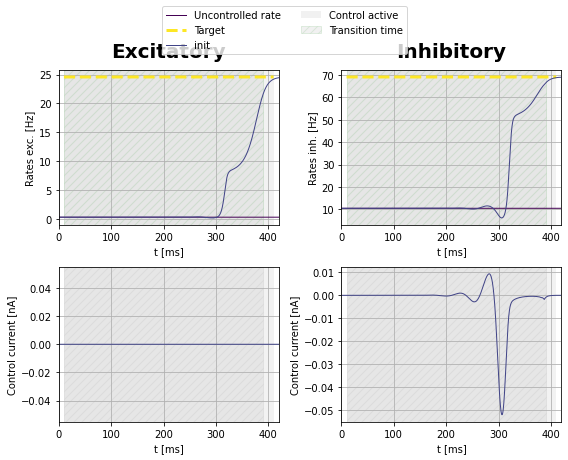

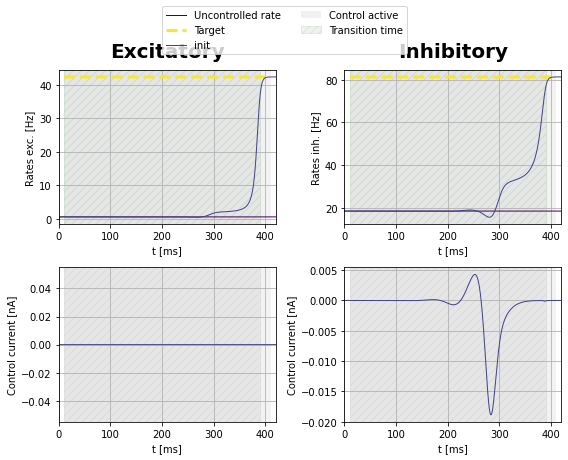

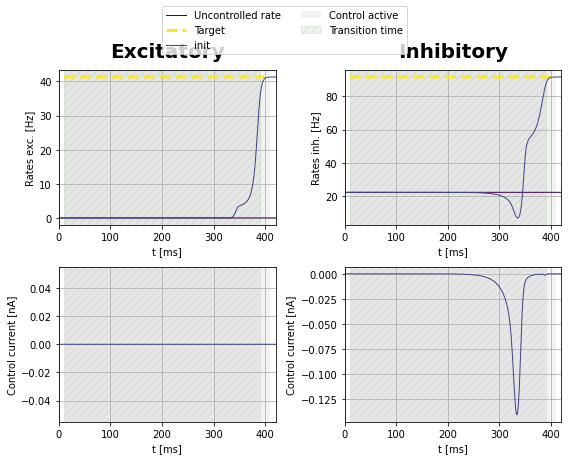

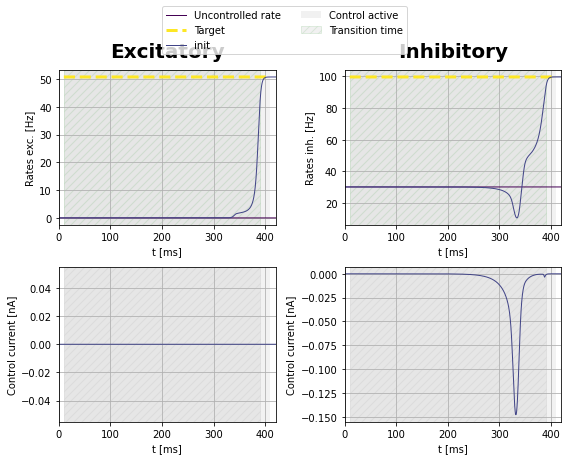

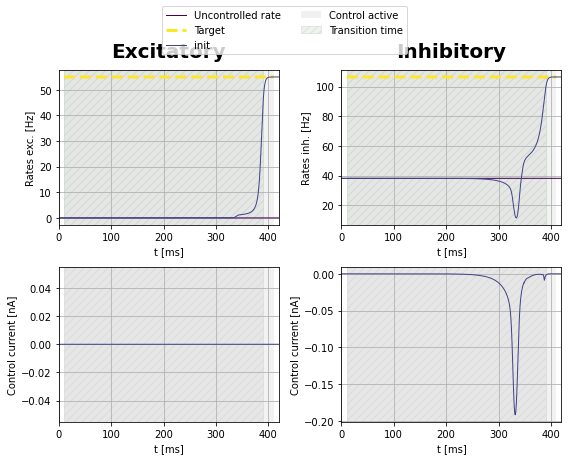

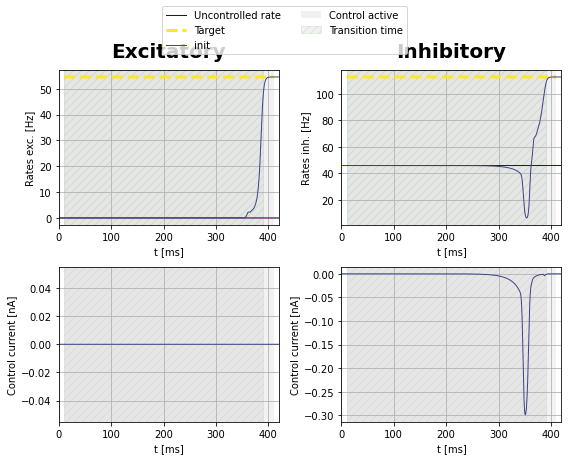

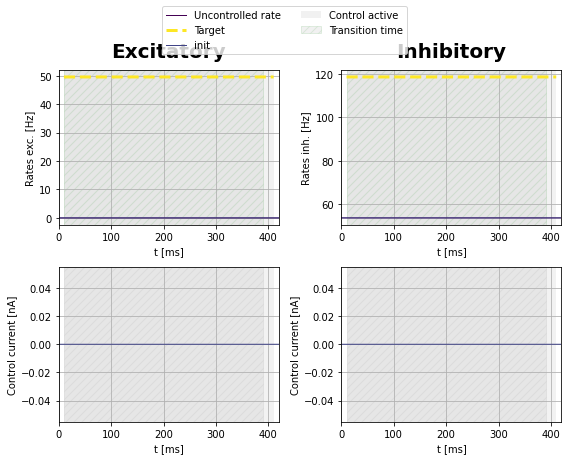

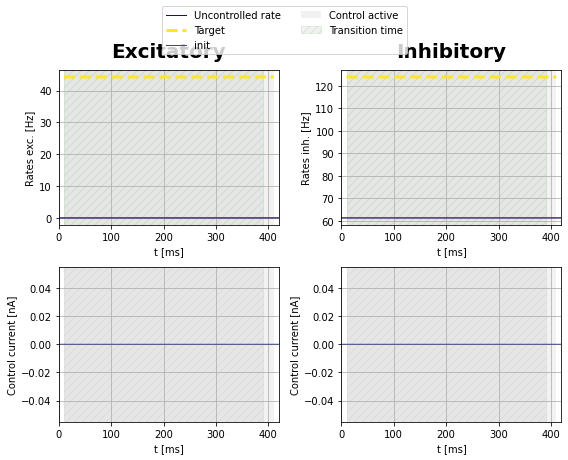

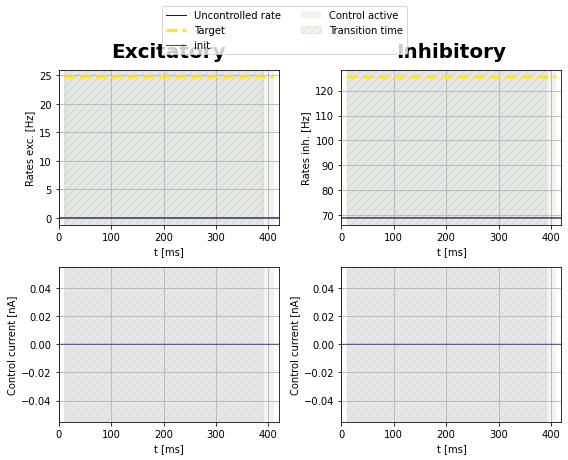

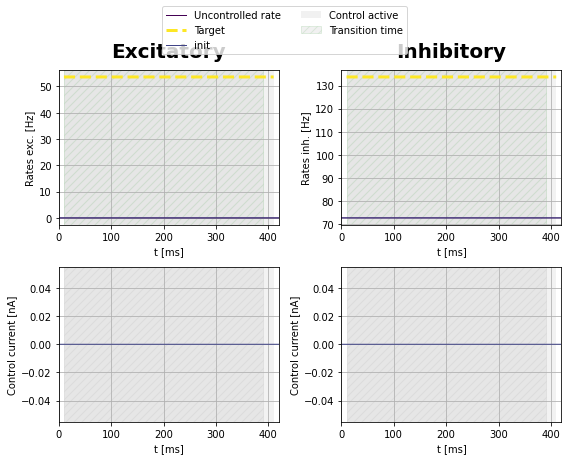

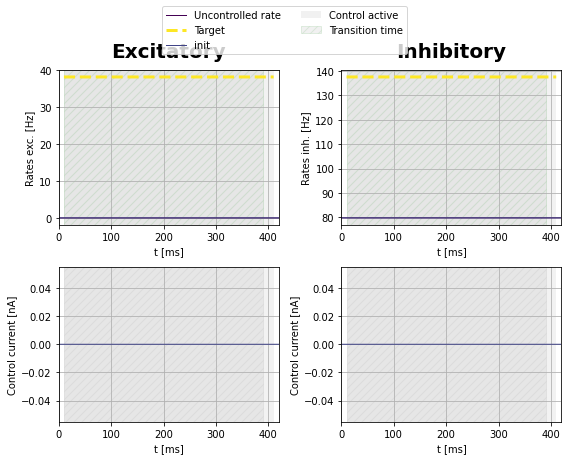

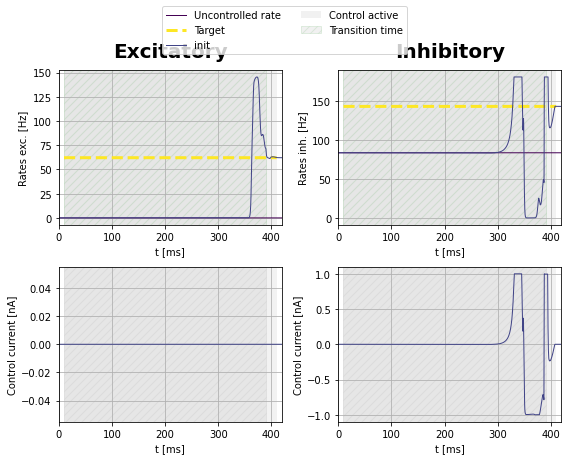

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
found solution for  13
-------  26 0.47500000000000014 0.4750000000000002
found so

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  67.31202543581323
Control only changes marginally.
RUN  51 , total integrated cost =  67.31202543581323
Improved over  51  iterations in  6.147796180099249  seconds by  99.72658766464099  percent.
Problem in initial value trasfer:  Vmean_exc -56.701923018358336 -56.70192296683721
weight =  3650.85645087274
set cost params:  1.0 0.0 3650.85645087274
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24502.736434660474
Gradient descend method:  None
RUN  1 , total integrated cost =  24133.813812288892
RUN  2 , total integrated cost =  24130.82475163845
RUN  3 , total integrated cost =  24130.57544269537
RUN  4 , total integrated cost =  24129.370953715443
RUN  5 , total integrated cost =  24128.746822926176
RUN  6 , total integrated cost =  24127.221089089966
RUN  7 , total integrated cost =  24125.2181257596
RUN  8 , total integrated cost =  24125.024951023417
RUN  9 , total integrated cost =  24106.621731394258
RUN  10 , total int

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  53 , total integrated cost =  24084.123293961766
Improved over  53  iterations in  6.443712130188942  seconds by  1.708434246987025  percent.
Problem in initial value trasfer:  Vmean_exc -56.70191593032632 -56.70191615320411
-------  91 0.5000000000000002 0.7250000000000004
[0, 13, 26, 39, 52, 65] []
closest index  65
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19656.532771792597
Gradient descend method:  None
RUN  1 , total integrated cost =  19612.79377961396
RUN  2 , total integrated cost =  19611.757917578234
RUN  3 , total integrated cost =  19611.739429323185
RUN  4 , total integrated cost =  19611.738761770823
RUN  5 , total integrated cost =  19611.738755065544
RUN  6 , total integrated cost =  19611.738754960774
RUN  7 , total integrated cost =  19611.738754959955
RUN  8 , total integrated cost =  19611.738754959948
RUN  9 , total integrated cost =  19611.7387

...

RUN  120 , total integrated cost =  132.81562699580925
Control only changes marginally.
RUN  121 , total integrated cost =  132.81562699580925
Improved over  121  iterations in  14.228067342191935  seconds by  97.83008308577489  percent.
Problem in initial value trasfer:  Vmean_exc -56.625521197790725 -56.62552102602361
-------  117 0.5500000000000003 0.8000000000000005
[0, 13, 26, 39, 52, 65] []
closest index  65
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28760.19792486903
Gradient descend method:  None
RUN  1 , total integrated cost =  28716.97978384798
RUN  2 , total integrated cost =  28715.56182270916
RUN  3 , total integrated cost =  28715.542004395604
RUN  4 , total integrated cost =  28715.541832793315
RUN  5 , total integrated cost =  28715.541829803402
RUN  6 , total integrated cost =  28715.54182973939
RUN  7 , total integrated cost =  28715.54182973778
RUN  8 , total integrated cost =  28715.5

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  339.0115261252581
Control only changes marginally.
RUN  5 , total integrated cost =  339.0115261252581
Improved over  5  iterations in  0.9626018442213535  seconds by  98.81941448942406  percent.
Problem in initial value trasfer:  Vmean_exc -56.70413726651228 -56.70413276721709
-------  130 0.47500000000000014 0.8500000000000005
[0, 13, 26, 39, 52, 65] []
closest index  65
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14592.775701428007
Gradient descend method:  None
RUN  1 , total integrated cost =  14549.025717598342
RUN  2 , total integrated cost =  14548.006587755084
RUN  3 , total integrated cost =  14547.97912193183
RUN  4 , total integrated cost =  14547.979044445787
RUN  5 , total integrated cost =  14547.97904339039
RUN  6 , total integrated cost =  14547.979043360214
RUN  7 , total integrated cost =  14547.979043359304
RUN  8 , total integrated cost =  14547.979043

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  88 , total integrated cost =  130.21340947957725
Improved over  88  iterations in  10.417163327336311  seconds by  99.10493815607319  percent.
Problem in initial value trasfer:  Vmean_exc -56.67729237458226 -56.677292418644356
-------  143 0.6000000000000003 0.8750000000000006
found solution for  143
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0, 13, 26, 39, 52, 65, 143]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
found solution for  78
-------  91 0.5000000000000002 0.7250000000000004
found solution for  91
----

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6197.271225920876
set cost params:  1.0 0.0 6197.271225920876
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.675464898992
Gradient descend method:  None
RUN  1 , total integrated cost =  5900.668796706986
RUN  2 , total integrated cost =  5900.668677376799
RUN  3 , total integrated cost =  5900.668655362884
RUN  4 , total integrated cost =  5900.668650784961
RUN  5 , total integrated cost =  5900.668649638146
RUN  6 , total integrated cost =  5900.668649421044
RUN  7 , total integrated cost =  5900.6686493649
RUN  8 , total integrated cost =  5900.668649349408
RUN  9 , total integrated cost =  5900.668649345263
RUN  10 , total integrated cost =  5900.6686493442185
RUN  11 , total integrated cos

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  5900.668649343846
RUN  16 , total integrated cost =  5900.668649343846
Control only changes marginally.
RUN  16 , total integrated cost =  5900.668649343846
Improved over  16  iterations in  1.8135170079767704  seconds by  0.0001155046602150378  percent.
Problem in initial value trasfer:  Vmean_exc -56.62692280900612 -56.62692767376266
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  42502.588899292736
set cost params:  1.0 0.0 42502.588899292736
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17550.386015445703
Gradient descend method:  None
RUN  1 , total integrated cost =  17550.383635085476
RUN  2 , total integrated cost =  17550.383618919557
RUN  3 , total integrated cost =  17550.383618877335
RUN  4 , total integrated cost =  17550.383618877295
RUN  5 , total integrated cost =  17550.38361887729
RUN  6 , total integrated cost =  17550.38361887728
RUN  7 , total integrated cost =  17550.38361887

ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  17550.38361887726
RUN  10 , total integrated cost =  17550.38361887726
Control only changes marginally.
RUN  10 , total integrated cost =  17550.38361887726
Improved over  10  iterations in  0.9652719013392925  seconds by  1.3655360291409124e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.69064336740819 -56.6906440734793
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  6466.1725071791425
set cost params:  1.0 0.0 6466.1725071791425
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17065.813249156658
Gradient descend method:  None
RUN  1 , total integrated cost =  17065.81100200571
RUN  2 , total integrated cost =  17065.811001185488
RUN  3 , total integrated cost =  17065.81100115571
RUN  4 , total integrated cost =  17065.811001155183


...

RUN  1 , total integrated cost =  6107.631584692487
Control only changes marginally.
RUN  1 , total integrated cost =  6107.631584692487
Improved over  1  iterations in  0.321895357221365  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62443714248528 -56.62444333079241
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  3347.401656624343
set cost params:  1.0 0.0 3347.401656624343
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28706.952428530392
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28706.952428530392
Control only changes marginally.
RUN  1 , total integrated cost =  28706.952428530392
Improved over  1  iterations in  0.3379970043897629  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.704082224673755 -56.7040822573049
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  1137.0631502200322
set cost params:  1.0 0.0 1137.0631502200322
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14535.195929483245
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14535.195929483245
Control only changes marginally.
RUN  1 , total integrated cost =  14535.195929483245
Improved over  1  iterations in  0.33135429210960865  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67709749448354 -56.67710225025009
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
[[True, False], [True, False], [False, False], [True, False], [True, True], [True, False], [True, True], [False, False], [False, False], [False, False], [False, False], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.675

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32.43360652229562
Gradient descend method:  None
RUN  1 , total integrated cost =  9.95268396897004
RUN  2 , total integrated cost =  9.87787997491824
RUN  3 , total integrated cost =  9.86274296635264
RUN  4 , total integrated cost =  9.855931048664
RUN  5 , total integrated cost =  9.851721484071556
RUN  6 , total integrated cost =  9.841061074854728
RUN  7 , total integrated cost =  9.83671995384725
RUN  8 , total integrated cost =  9.836090500239955
RUN  9 , total integrated cost =  9.8349502675505
RUN  10 , total integrated cost =  9.834598786445975
RUN  11 , total integrated cost =  9.834137139536928
RUN  12 , total integrated cost =  9.833886339326787
RUN  13 , total integrated cost =  9.833051634706331
RUN  14 , total integrated cost =  9.832498725850835
RUN  15 , total integrated cost =  9.832423687217556
RUN  16 , total integr

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  55 , total integrated cost =  9.82740397575329
Improved over  55  iterations in  12.38983491435647  seconds by  69.69993463724825  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762274547194 -56.62762266741176
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  98.09262088873636
Gradient descend method:  HS
RUN  1 , total integrated cost =  97.49276080517062
RUN  2 , total integrated cost =  97.44616760568965
RUN  3 , total integrated cost =  97.39241324155536
RUN  4 , total integrated cost =  97.38031316877743
RUN  5 , total integrated cost =  97.2864533319833
RUN  6 , total integrated cost =  97.24873374984811
RUN  7 , total integrated cost =  97.18408666808189
RUN  8 , total integrated cost =  97.11946735171595
RUN  9 , total integrated cost =  97.09765611104915
RUN  10 , total integrated cost =  97.0385373267878
RUN  11 , total integrated cost =  97.03046341167476
RU

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  65 , total integrated cost =  95.83077664939329
Improved over  65  iterations in  12.395648263394833  seconds by  2.305825064974684  percent.
Problem in initial value trasfer:  Vmean_exc -56.627563592156484 -56.627564082384716
weight =  6158.197165679813
set cost params:  1.0 0.0 6158.197165679813
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5879.022004043149
Gradient descend method:  None
RUN  1 , total integrated cost =  5829.626724508095
RUN  2 , total integrated cost =  5829.542413610586
RUN  3 , total integrated cost =  5829.521278681561
RUN  4 , total integrated cost =  5829.413384790185
RUN  5 , total integrated cost =  5829.254136251863
RUN  6 , total integrated cost =  5829.241097912566
RUN  7 , total integrated cost =  5829.0192612906
RUN  8 , total integrated cost =  5828.737477624689
RUN  9 , total integrated cost =  5828.727686141728
RUN  10 , total integrated cost =  5828.478590455529
RUN  11 , total integra

...

RUN  1 , total integrated cost =  393.53680719192255
Control only changes marginally.
RUN  1 , total integrated cost =  393.53680719192255
Improved over  1  iterations in  0.8869526870548725  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700108094404456 -56.70011928623659
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3827.0839055753067
Gradient descend method:  HS


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3827.0839055753067
Control only changes marginally.
RUN  1 , total integrated cost =  3827.0839055753067
Improved over  1  iterations in  0.8962896969169378  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700108094404456 -56.70011928623659
weight =  1007.9408261715259
set cost params:  1.0 0.0 1007.9408261715259
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38465.50156340926
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  38465.50156340926
Control only changes marginally.
RUN  1 , total integrated cost =  38465.50156340926
Improved over  1  iterations in  0.8880767468363047  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700108094404456 -56.70011928623659


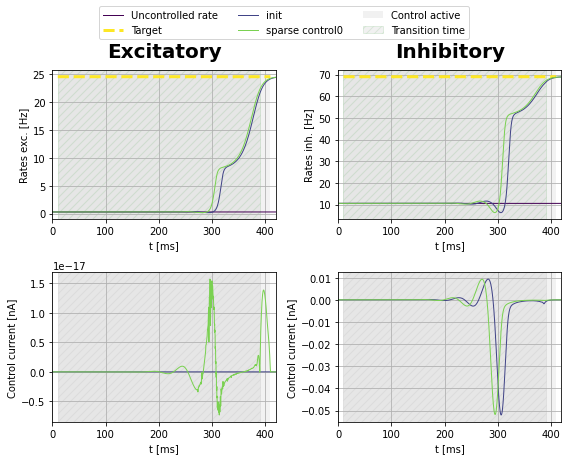

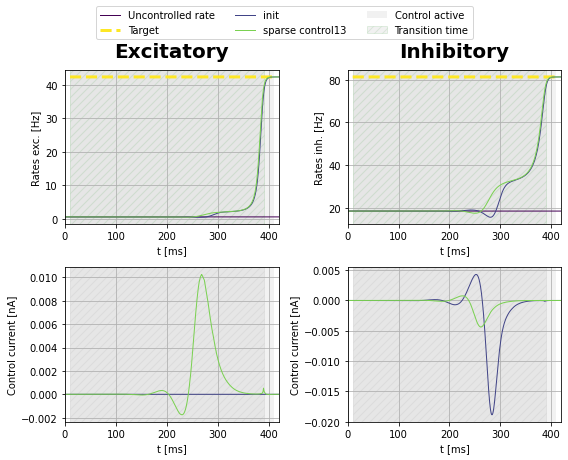

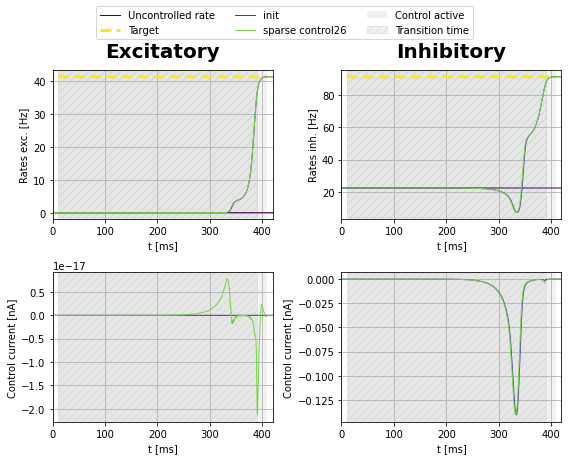

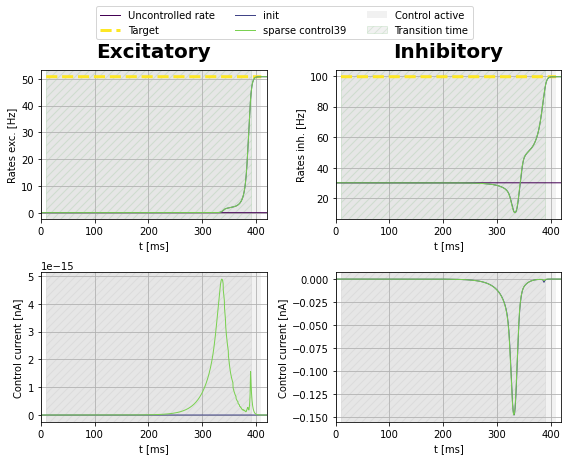

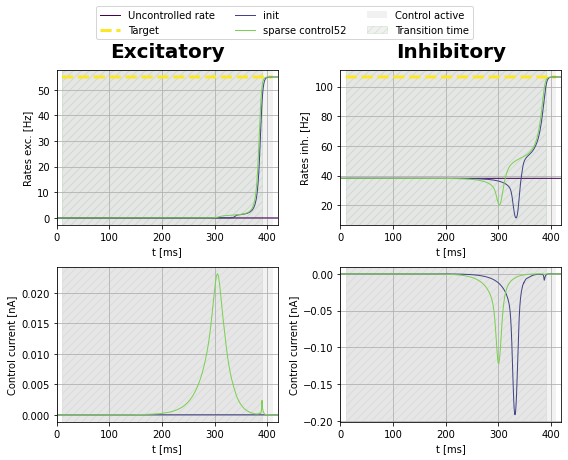

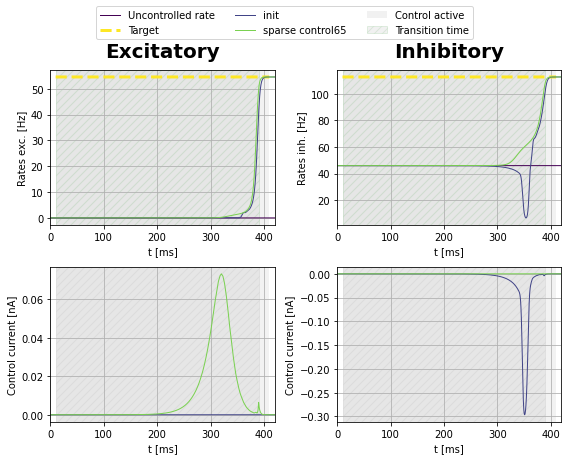

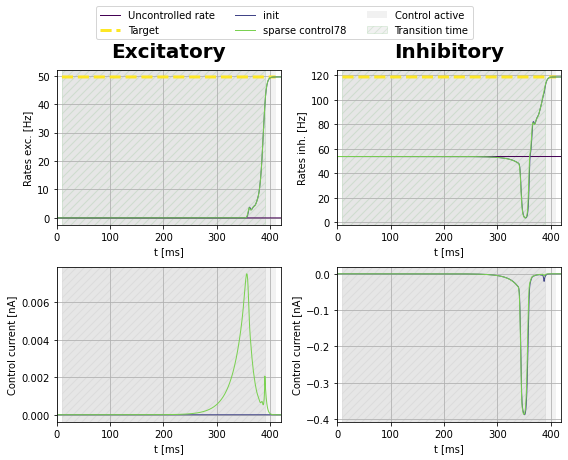

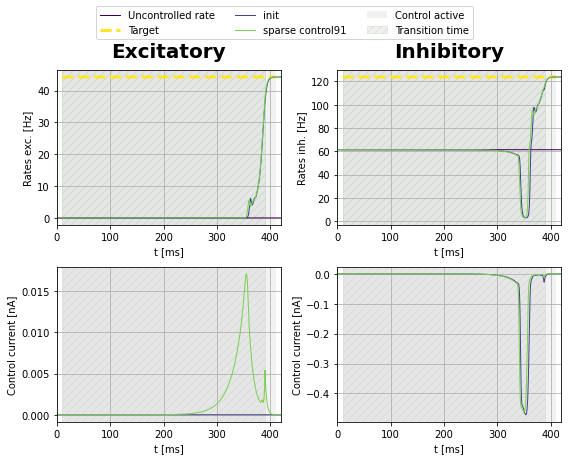

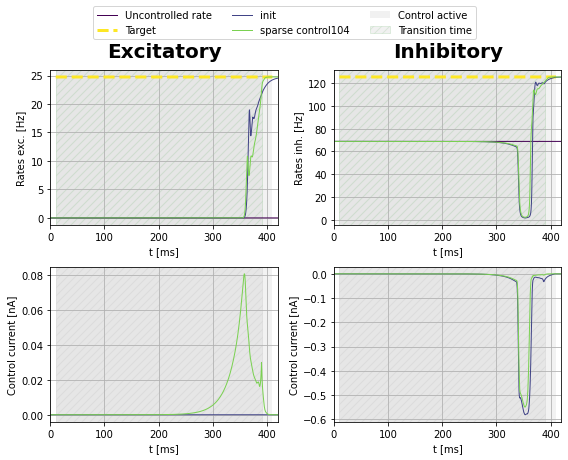

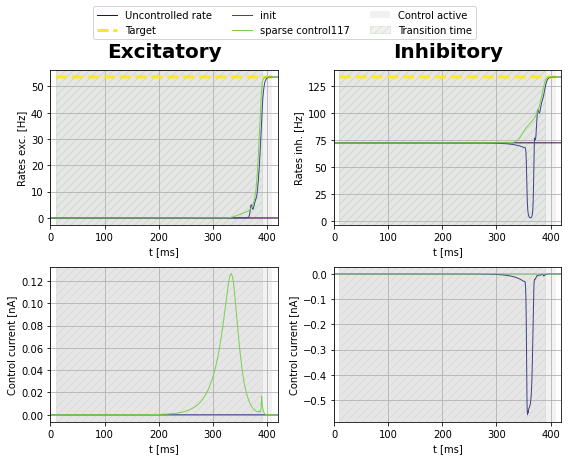

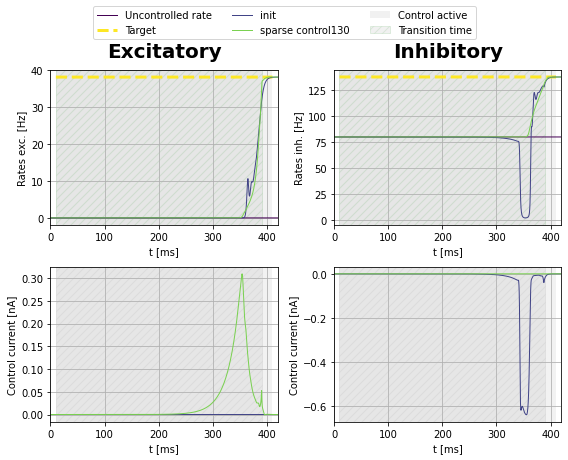

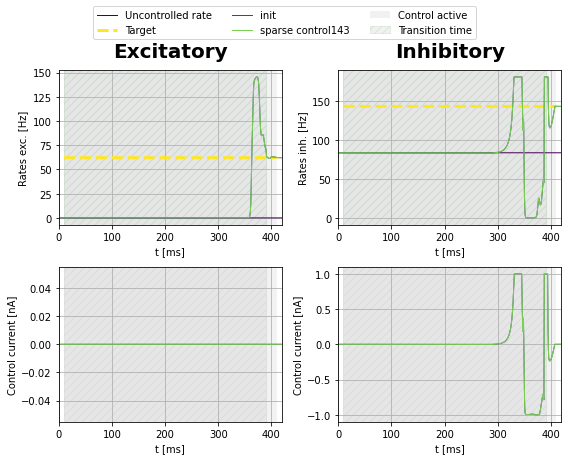

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6240.0435326335455
set cost params:  1.0 0.0 6240.0435326335455
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.288658052633
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.287750198167
RUN  2 , total integrated cost =  5901.28775019815


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  5901.28775019815
Control only changes marginally.
RUN  3 , total integrated cost =  5901.28775019815
Improved over  3  iterations in  1.4567284043878317  seconds by  1.5384003987151118e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.62707914317296 -56.62708496764942
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  46188.929160049
set cost params:  1.0 0.0 46188.929160049
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17550.600172708782
Gradient descend method:  None
RUN  1 , total integrated cost =  17550.277291534632
RUN  2 , total integrated cost =  17549.903487964635
RUN  3 , total integrated cost =  17549.632468597578
RUN  4 , total integrated cost =  17549.305373258125
RUN  5 , total integrated cost =  17549.076133925457
RUN  6 , total integrated cost =  17548.81279187921
RUN  7 , total integrated cost =  17548.62003017551
RUN  8 , total integrated cost =  17548.43118729629
RUN  9

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  3196 , total integrated cost =  16796.70353538456
Improved over  3196  iterations in  440.49878198467195  seconds by  4.2955604361412725  percent.
Problem in initial value trasfer:  Vmean_exc -56.69065222931052 -56.69065265320288
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  6472.516370839972
set cost params:  1.0 0.0 6472.516370839972
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17066.028581352515
Gradient descend method:  None
RUN  1 , total integrated cost =  17066.02797749703
RUN  2 , total integrated cost =  17066.027970723615
RUN  3 , total integrated cost =  17066.0279707064
RUN  4 , total integrated cost =  17066.027970705894
RUN  5 , total integrated cost =  17066.027970705883


...

RUN  1 , total integrated cost =  17550.784179892675
Control only changes marginally.
RUN  1 , total integrated cost =  17550.784179892675
Improved over  1  iterations in  0.4996310640126467  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.690651878368435 -56.6906523134911
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
no convergence
weight =  473.79218731681533
set cost params:  1.0 0.0 473.79218731681533
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6107.878688663867
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  6107.878688663867
Control only changes marginally.
RUN  1 , total integrated cost =  6107.878688663867
Improved over  1  iterations in  0.4492963757365942  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62553006517511 -56.62552968739125
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  8775.604781402382
set cost params:  1.0 0.0 8775.604781402382
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28712.270001662513
Gradient descend method:  None
RUN  1 , total integrated cost =  28712.270001662513
Control only changes marginally.
RUN  1 , total integrated cost =  28712.270001662513
Improved over  1  iterations in  0.4977519288659096  seconds by  0.0  percent.
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  2204.7798003942385
set cost params:  1.0 0.0 2204.7798003942385
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14541.3836

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14541.383652895922
Control only changes marginally.
RUN  1 , total integrated cost =  14541.383652895922
Improved over  1  iterations in  0.48847486451268196  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67732082551411 -56.67731876114756
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 4
[[True, True], [False, False], [True, False], [True, True], [True, False], [True, True], [True, False], [True, False], [False, False], [False, False], [False, False], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.525000

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.034839969537478
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9932932798189057
RUN  2 , total integrated cost =  0.9830036244497382
RUN  3 , total integrated cost =  0.9794473854702539
RUN  4 , total integrated cost =  0.9702628651223063
RUN  5 , total integrated cost =  0.9701781200859666
RUN  6 , total integrated cost =  0.970119680839493
RUN  7 , total integrated cost =  0.9700145832683581
RUN  8 , total integrated cost =  0.9699421647172614
RUN  9 , total integrated cost =  0.9695267550631301
RUN  10 , total integrated cost =  0.9693190497127978
RUN  11 , total integrated cost =  0.9692975653692174
RUN  12 , total integrated cost =  0.969264333353831
RUN  13 , total integrated cost =  0.9692543938680637
RUN  14 , total integrated cost =  0.969199952764881
RUN  15 , total integrated cost =  0.9691605544850929
R

RUN  6 , total integrated cost =  1.4735534179759135
RUN  7 , total integrated cost =  1.4735447381836702
RUN  8 , total integrated cost =  1.4735447366928482
RUN  9 , total integrated cost =  1.4735447366876833
RUN  10 , total integrated cost =  1.4735447366876737
RUN  11 , total integrated cost =  1.4735447366876717
RUN  12 , total integrated cost =  1.4735447366876713
RUN  13 , total integrated cost =  1.4735447366876686
RUN  14 , total integrated cost =  1.4735447366876673
RUN  15 , total integrated cost =  1.4735447366876673
Control only changes marginally.
RUN  15 , total integrated cost =  1.4735447366876673
Improved over  15  iterations in  1.0780360884964466  seconds by  93.02771569779199  percent.
-------  65 0.5500000000000003 0.6250000000000003
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28.42063687553086
Gradient descend method:  None
RUN  1 , total integrated cost =  2.1982959558989106
RUN  2 , total integrated cos

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  304 , total integrated cost =  8.810187815079386
Improved over  304  iterations in  19.645539462566376  seconds by  80.68176381354796  percent.
Problem in initial value trasfer:  Vmean_exc -56.69409168996712 -56.6940916532324
-------  104 0.4250000000000001 0.7750000000000005
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15.806088299109241
Gradient descend method:  None
RUN  1 , total integrated cost =  14.013889548674115
RUN  2 , total integrated cost =  14.01349143440677
RUN  3 , total integrated cost =  14.013440688133006
RUN  4 , total integrated cost =  14.013439959481456
RUN  5 , total integrated cost =  14.013439917663385
RUN  6 , total integrated cost =  14.01343991326209
RUN  7 , total integrated cost =  14.013439912770217
RUN  8 , total integrated cost =  14.01343991271155
RUN  9 , total integrated cost =  14.01343991270418
RUN  10 , total integrated cost =  14.013439912703353
RUN  1

ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  14.013439912703223
RUN  15 , total integrated cost =  14.013439912703223
Control only changes marginally.
RUN  15 , total integrated cost =  14.013439912703223
Improved over  15  iterations in  1.0475355871021748  seconds by  11.34150557989129  percent.
Problem in initial value trasfer:  Vmean_exc -56.625816819654986 -56.62581372108774
-------  117 0.5500000000000003 0.8000000000000005
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  27.34947978385052
Gradient descend method:  None
RUN  1 , total integrated cost =  3.634164842115851
RUN  2 , total integrated cost =  3.6235897757262197
RUN  3 , total integrated cost =  3.6224152782318635
RUN  4 , total integrated cost =  3.6212793861709307
RUN  5 , total integrated cost =  3.620750177586801
RUN  6 , total integrated cost =  3.6201445611140475
RUN  7 , total integrated cost =  3.6199484683542615
RUN  8 , total integrated cost =  3.6196543062274187
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  39 , total integrated cost =  8.995024183586764
Improved over  39  iterations in  2.71863766759634  seconds by  45.55143005755997  percent.
Problem in initial value trasfer:  Vmean_exc -56.677360426980215 -56.67735766476348
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50.182097353584105
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  50.182097353584105
Control only changes marginally.
RUN  1 , total integrated cost =  50.182097353584105
Improved over  1  iterations in  0.2853475697338581  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700108094404456 -56.70011928623659


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9681175265583086
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9681175265583086
Control only changes marginally.
RUN  1 , total integrated cost =  0.9681175265583086
Improved over  1  iterations in  0.1588492300361395  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.36680979668291697
Gradient descend method:  None
RUN  1 , total integrated cost =  0.36680979668291697
Control only changes marginally.
RUN  1 , total integrated cost =  0.366809796682

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  8.810187815079386
Control only changes marginally.
RUN  1 , total integrated cost =  8.810187815079386
Improved over  1  iterations in  0.16268768347799778  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69409168996712 -56.6940916532324
-------  104 0.4250000000000001 0.7750000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.013439912703223
Gradient descend method:  None
RUN  1 , total integrated cost =  14.013439912703223
Control only changes marginally.
RUN  1 , total integrated cost =  14.013439912703223
Improved over  1  iterations in  0.17299611493945122  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.625816819654986 -56.62581372108774
-------  117 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.6142428295

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  8.995024183586764
Control only changes marginally.
RUN  1 , total integrated cost =  8.995024183586764
Improved over  1  iterations in  0.1674415022134781  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.677360426980215 -56.67735766476348
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 11
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  7

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
